# Final Dataset Construction

In [1]:
import pandas as pd
import ast
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.colors as mcolors

import warnings
warnings.filterwarnings("ignore")

In [4]:
def safe_literal_eval(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return []
    return []
    
def priority(row):
    if pd.notna(row['APC_Accounting_Value']):
        return row['APC_Accounting_Value'], 'APC_Accounting_Value'
    if pd.notna(row['euro']):
        return row['euro'], 'Open APC'
    if pd.notna(row['median']):
        return row['median'], 'Open APC Median'
    else:
        return row['value_usd_to_eur'], 'APC_paid'
        
def price(row):
    if 0 in row['french_position']:
        return row['First_pct'] * row['price_var']
    if row['len'] - 1 in row['french_position']:
        return row['Last_pct'] * row['price_var']
    else:
        return len(row['french_position']) * row['price_var'] * row['len'] / (row['len'] - 2)

## Price methodology

Based on Open APC

In [12]:
df_inclusive = pd.read_csv('../data/processed/main_dataset.csv')
df_inclusive_paid = df_inclusive[df_inclusive.apc_paid.notna()].reset_index(drop = True)
df_money = pd.read_csv('EUR_USD_yearly_avg_2013_2025.csv').set_index('year')

df_inclusive_paid['apc_paid'] = df_inclusive_paid.apc_paid.apply(safe_literal_eval)
df_inclusive_paid['value_usd'] = df_inclusive_paid.apc_paid.apply(lambda x: x['value_usd'])
df_inclusive_paid['value_usd_to_eur'] = df_inclusive_paid.apply(lambda x: x['value_usd']*df_money.at[x['publication_year'], 'avg_eur_per_usd'], axis = 1)

interest_cols = ['doi', 'euro', 'issn_l', 'period', 'institution']
df_open_apc = pd.read_csv('../data/processed/apc_de.csv')[interest_cols]
df_inclusive_paid = df_inclusive_paid.merge(df_open_apc[['doi', 'euro', 'institution']], on = 'doi', how = 'left')
print('Dois with apc_paid: ', len(df_inclusive_paid), 'Dois with apc_paid to infer: ', len(df_inclusive_paid[df_inclusive_paid.First_Last_FR.isna()]))
print('Dois with apc_paid from open_apc: ', len(df_inclusive_paid[df_inclusive_paid.euro.notna()]))
df_inclusive_paid

Dois with apc_paid:  163075 Dois with apc_paid to infer:  48026
Dois with apc_paid from open_apc:  26638


,doi,publication_year,language,issn_l,oa_status,apc_paid,corresponding,countries,has_fr_corresponding,BSO,...,priority,First_Last_FR,First_pct,Last_pct,Middle_pct,publisher,value_usd,value_usd_to_eur,euro,institution
0,10.3389/fnins.2013.00267,2013,en,1662-453X,gold,"{'value': 2950, 'currency': 'USD', 'value_usd'...",[True],"[['FR', 'US']]",True,True,...,3.0,NaN,NaN,NaN,NaN,Frontiers Media SA,2950,2227.146004,NaN,NaN
1,10.1016/j.mattod.2013.06.004,2013,en,1369-7021,hybrid,"{'value': 5300, 'currency': 'USD', 'value_usd'...",[True],[['FR']],True,True,...,3.0,NaN,NaN,NaN,NaN,Elsevier BV,5300,4001.313159,NaN,NaN
2,10.3390/pathogens3010014,2013,en,2076-0817,gold,"{'value': 2200, 'currency': 'CHF', 'value_usd'...",[True],[['FR']],True,True,...,3.0,NaN,NaN,NaN,NaN,MDPI AG,2382,1798.326027,NaN,NaN
3,10.5194/gmd-6-373-2013,2013,en,1991-959X,gold,"{'value': 1600, 'currency': 'EUR', 'value_usd'...",[True],[['FR']],True,True,...,3.0,NaN,NaN,NaN,NaN,Copernicus GmbH,1725,1302.314189,NaN,NaN
4,10.1371/journal.pcbi.1003149,2013,en,1553-734X,gold,"{'value': 2655, 'currency': 'USD', 'value_usd'...",[True],[['FR']],True,True,...,3.0,NaN,NaN,NaN,NaN,Public Library of Science (PLoS),2655,2004.431403,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163070,10.1016/j.ebiom.2022.103935,2022,en,2352-3964,gold,"{'value': 3500, 'currency': 'USD', 'value_usd'...",[True],[['FR']],NaN,True,...,NaN,True,0.655172,0.310345,0.034483,Elsevier BV,3500,3323.747497,NaN,NaN
163071,10.1016/j.eats.2022.11.012,2023,en,2212-6287,gold,"{'value': 975, 'currency': 'USD', 'value_usd':...",[True],[['FR']],NaN,True,...,NaN,True,0.722222,0.250000,0.027778,Elsevier BV,975,904.758675,NaN,NaN
163072,10.1016/j.jbc.2023.103941,2023,en,0021-9258,gold,"{'value': 2500, 'currency': 'USD', 'value_usd'...",[True],[['FR']],NaN,True,...,NaN,True,0.585366,0.390244,0.024390,Elsevier BV,2500,2319.894037,NaN,NaN
163073,10.1016/j.jfa.2024.110530,2024,en,0022-1236,hybrid,"{'value': 2560, 'currency': 'USD', 'value_usd'...",[True],[['FR']],NaN,True,...,NaN,True,0.820000,0.140000,0.040000,Elsevier BV,2560,2362.400141,NaN,NaN


**Manually correction of no french institutions in open apc**

In [13]:
df_tmp = pd.read_csv('Miscellaneous - OpenAPC_v2.csv').drop(columns = 'doi')
df_tmp_not_french = df_tmp[df_tmp['Not France'] == True].institution.unique()
print('Dois with apc_paid from open_apc: ', len(df_inclusive_paid[df_inclusive_paid.euro.notna()]))
df_inclusive_paid['euro'] = df_inclusive_paid.apply(lambda row: np.nan if pd.notna(row['euro']) and row['institution'] in df_tmp_not_french else row['euro'],  axis = 1)
df_inclusive_paid = df_inclusive_paid.drop(columns = 'institution')
print('Dois with apc_paid after filtering: ', len(df_inclusive_paid[df_inclusive_paid.euro.notna()]))
df_inclusive_paid

Dois with apc_paid from open_apc:  26638
Dois with apc_paid after filtering:  25247


,doi,publication_year,language,issn_l,oa_status,apc_paid,corresponding,countries,has_fr_corresponding,BSO,...,position,priority,First_Last_FR,First_pct,Last_pct,Middle_pct,publisher,value_usd,value_usd_to_eur,euro
0,10.3389/fnins.2013.00267,2013,en,1662-453X,gold,"{'value': 2950, 'currency': 'USD', 'value_usd'...",[True],"[['FR', 'US']]",True,True,...,First,3.0,NaN,NaN,NaN,NaN,Frontiers Media SA,2950,2227.146004,NaN
1,10.1016/j.mattod.2013.06.004,2013,en,1369-7021,hybrid,"{'value': 5300, 'currency': 'USD', 'value_usd'...",[True],[['FR']],True,True,...,First,3.0,NaN,NaN,NaN,NaN,Elsevier BV,5300,4001.313159,NaN
2,10.3390/pathogens3010014,2013,en,2076-0817,gold,"{'value': 2200, 'currency': 'CHF', 'value_usd'...",[True],[['FR']],True,True,...,First,3.0,NaN,NaN,NaN,NaN,MDPI AG,2382,1798.326027,NaN
3,10.5194/gmd-6-373-2013,2013,en,1991-959X,gold,"{'value': 1600, 'currency': 'EUR', 'value_usd'...",[True],[['FR']],True,True,...,First,3.0,NaN,NaN,NaN,NaN,Copernicus GmbH,1725,1302.314189,NaN
4,10.1371/journal.pcbi.1003149,2013,en,1553-734X,gold,"{'value': 2655, 'currency': 'USD', 'value_usd'...",[True],[['FR']],True,True,...,First,3.0,NaN,NaN,NaN,NaN,Public Library of Science (PLoS),2655,2004.431403,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163070,10.1016/j.ebiom.2022.103935,2022,en,2352-3964,gold,"{'value': 3500, 'currency': 'USD', 'value_usd'...",[True],[['FR']],NaN,True,...,NaN,NaN,True,0.655172,0.310345,0.034483,Elsevier BV,3500,3323.747497,NaN
163071,10.1016/j.eats.2022.11.012,2023,en,2212-6287,gold,"{'value': 975, 'currency': 'USD', 'value_usd':...",[True],[['FR']],NaN,True,...,NaN,NaN,True,0.722222,0.250000,0.027778,Elsevier BV,975,904.758675,NaN
163072,10.1016/j.jbc.2023.103941,2023,en,0021-9258,gold,"{'value': 2500, 'currency': 'USD', 'value_usd'...",[True],[['FR']],NaN,True,...,NaN,NaN,True,0.585366,0.390244,0.024390,Elsevier BV,2500,2319.894037,NaN
163073,10.1016/j.jfa.2024.110530,2024,en,0022-1236,hybrid,"{'value': 2560, 'currency': 'USD', 'value_usd'...",[True],[['FR']],NaN,True,...,NaN,NaN,True,0.820000,0.140000,0.040000,Elsevier BV,2560,2362.400141,NaN


**Direct total cost case**

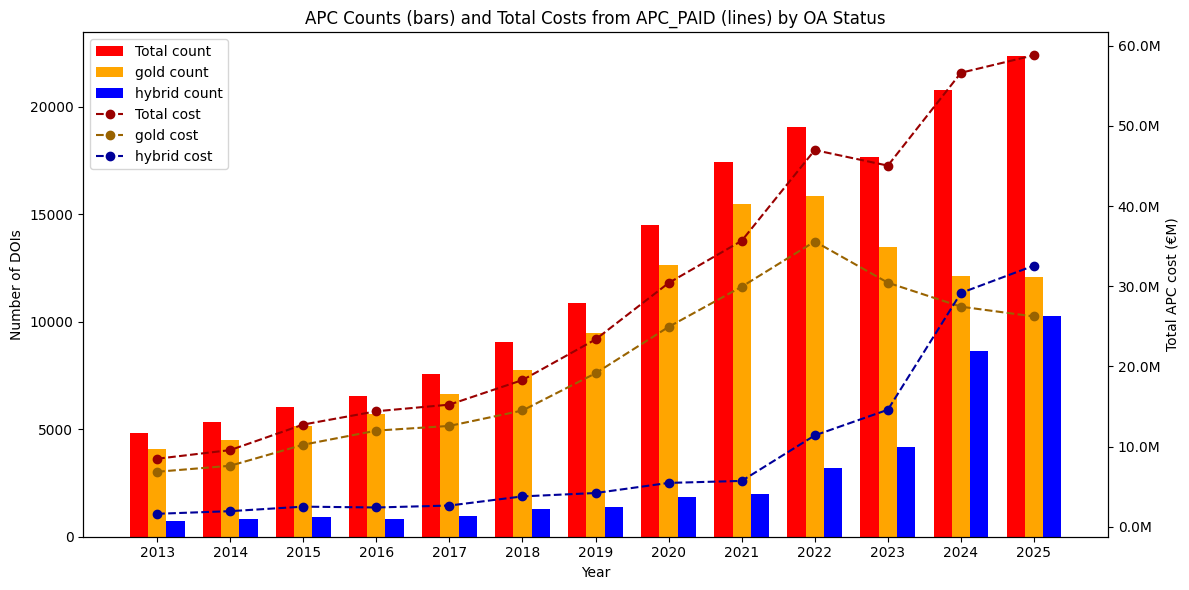

In [14]:
df_inclusive_paid_tmp_0 = df_inclusive_paid.copy()
df_inclusive_paid_tmp_0['fr_cost'] = df_inclusive_paid_tmp_0.value_usd_to_eur

df_inclusive_paid_tmp_0_oa_gold_hyb = df_inclusive_paid_tmp_0[df_inclusive_paid_tmp_0.oa_status.isin(['hybrid', 'gold'])].reset_index(drop = True)
status = df_inclusive_paid_tmp_0_oa_gold_hyb.groupby(['publication_year', 'oa_status']).agg({'doi':'count', 'fr_cost': 'sum'})
total = df_inclusive_paid_tmp_0_oa_gold_hyb.groupby(['publication_year']).agg({'doi':'count', 'fr_cost': 'sum'})
total['oa_status'] = 'Total'
total = total.set_index('oa_status', append=True)
df_data = pd.concat([status, total]).sort_index()

bar_width = 0.25
years = sorted(df_inclusive_paid_tmp_0_oa_gold_hyb.publication_year.unique())
x = np.arange(len(years))

fig, ax1 = plt.subplots(figsize=(12,6))

colors = {'gold':'orange', 'hybrid':'blue', 'Total':'red'}

def darken_color(color, amount=0.6):
    c = mcolors.to_rgb(color)
    return (c[0]*amount, c[1]*amount, c[2]*amount)

count_df = df_data['doi'].unstack('oa_status').fillna(0)
for i, col in enumerate(count_df.columns):
    ax1.bar(x + i*bar_width, count_df[col], width=bar_width, color=colors.get(col,'grey'), label=f"{col} count")

ax1.set_ylabel('Number of DOIs')
ax1.set_xlabel('Year')
ax1.set_xticks(x + bar_width)  # center x-ticks under grouped bars
ax1.set_xticklabels(years)

cost_df = df_data['fr_cost'].unstack('oa_status').fillna(0)
ax2 = ax1.twinx()
for col in cost_df.columns:
    dark_color = darken_color(colors.get(col,'grey'))
    ax2.plot(x + bar_width, cost_df[col], color=dark_color, marker='o', linestyle='--', label=f"{col} cost")

ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x*1e-6:.1f}M'))

ax2.set_ylabel('Total APC cost (€M)')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title('APC Counts (bars) and Total Costs from APC_PAID (lines) by OA Status')
plt.tight_layout()
plt.show()

In [15]:
cost_df

oa_status,Total,gold,hybrid
publication_year,,,
2013,8.493633e+06,6.867325e+06,1.626307e+06
2014,9.571899e+06,7.617055e+06,1.954844e+06
2015,1.276002e+07,1.024189e+07,2.518132e+06
2016,1.441573e+07,1.200138e+07,2.414348e+06
2017,1.524319e+07,1.258761e+07,2.655584e+06
2018,1.830891e+07,1.451115e+07,3.797759e+06
2019,2.337300e+07,1.915548e+07,4.217521e+06
2020,3.041757e+07,2.493910e+07,5.478471e+06
2021,3.567779e+07,2.994901e+07,5.728781e+06


**Detect outliers**

In [16]:
print('Initial number of dois: ', len(df_open_apc))
df_open_apc['log_price'] = np.log1p(df_open_apc['euro'])
journal_stats = (df_open_apc.groupby('issn_l')['log_price'].agg(median = 'median', mad = lambda x: np.median(np.abs(x - np.median(x))), count = 'size').reset_index())

df_open_apc = df_open_apc.merge(journal_stats, on = 'issn_l', how = 'left')
df_open_apc['journal_mad_score'] = np.abs(df_open_apc['log_price'] - df_open_apc['median']) / df_open_apc['mad']

df_open_apc['is_outlier'] = ((df_open_apc['count'] >= 10) & (df_open_apc['journal_mad_score'] > 4))

df_open_apc = df_open_apc[df_open_apc.is_outlier == False].reset_index(drop = True)
print('Dois to use for inference: ', len(df_open_apc[df_open_apc.is_outlier == False]))
df_open_apc

Initial number of dois:  256534
Dois to use for inference:  241837


,doi,euro,issn_l,period,institution,log_price,median,mad,count,journal_mad_score,is_outlier
0,10.3389/fpsyg.2013.00318,960.00,1664-1078,2013,Bamberg U,6.867974,7.601002,0.200280,3332.0,3.660008,False
1,10.3389/fpsyg.2013.00406,960.00,1664-1078,2013,Bamberg U,6.867974,7.601002,0.200280,3332.0,3.660008,False
2,10.3389/fpsyg.2013.00453,960.00,1664-1078,2013,Bamberg U,6.867974,7.601002,0.200280,3332.0,3.660008,False
3,10.6000/1929-4409.2013.02.32,182.00,1929-4409,2013,Bamberg U,5.209486,5.744060,0.534574,3.0,1.000000,False
4,10.1068/i0605,405.79,2041-6695,2013,Bamberg U,6.008297,6.267513,0.314498,78.0,0.824223,False
...,...,...,...,...,...,...,...,...,...,...,...
241832,10.3390/mti9070072,1928.90,2414-4088,2025,University of Turku,7.565223,7.258743,0.263051,33.0,1.165098,False
241833,10.1098/rsos.250490,1581.30,2054-5703,2025,University of Turku,7.366635,7.159447,0.172074,228.0,1.204059,False
241834,10.3389/frcha.2025.1637011,2117.31,2813-4540,2025,University of Turku,7.658374,7.707267,0.042535,4.0,1.149487,False
241835,10.1093/femsec/fiaf081,2298.71,0168-6496,2025,University of Turku,7.740538,7.934986,0.103853,41.0,1.872332,False


**Median method**

In [17]:
threshold = 3 # Minimum number of data points per journal-year to be included in the median calculation
grouped = df_open_apc.groupby(['issn_l', 'period'])['euro'].agg(median = 'median', count = 'size')
grouped = grouped[grouped['count'] > threshold].reset_index().drop(columns = 'count')
print('Dois to use for inference: ', len(df_open_apc[df_open_apc.issn_l.isin(grouped.issn_l)]), 'Unique journals: ', grouped.issn_l.nunique())

df_inclusive_paid_tmp_1 = df_inclusive_paid.merge(grouped, left_on = ['issn_l', 'publication_year'], right_on = ['issn_l', 'period'], how = 'left').drop(columns = 'period')
print('Dois with inferred APC costs using open APC: ', len(df_inclusive_paid_tmp_1[(df_inclusive_paid_tmp_1['median'].notna()) & (df_inclusive_paid.euro.isna())  & (df_inclusive_paid.APC_Accounting_Value.isna())]))
df_inclusive_paid_tmp_1

Dois to use for inference:  216204 Unique journals:  2832
Dois with inferred APC costs using open APC:  70714


,doi,publication_year,language,issn_l,oa_status,apc_paid,corresponding,countries,has_fr_corresponding,BSO,...,priority,First_Last_FR,First_pct,Last_pct,Middle_pct,publisher,value_usd,value_usd_to_eur,euro,median
0,10.3389/fnins.2013.00267,2013,en,1662-453X,gold,"{'value': 2950, 'currency': 'USD', 'value_usd'...",[True],"[['FR', 'US']]",True,True,...,3.0,NaN,NaN,NaN,NaN,Frontiers Media SA,2950,2227.146004,NaN,NaN
1,10.1016/j.mattod.2013.06.004,2013,en,1369-7021,hybrid,"{'value': 5300, 'currency': 'USD', 'value_usd'...",[True],[['FR']],True,True,...,3.0,NaN,NaN,NaN,NaN,Elsevier BV,5300,4001.313159,NaN,NaN
2,10.3390/pathogens3010014,2013,en,2076-0817,gold,"{'value': 2200, 'currency': 'CHF', 'value_usd'...",[True],[['FR']],True,True,...,3.0,NaN,NaN,NaN,NaN,MDPI AG,2382,1798.326027,NaN,NaN
3,10.5194/gmd-6-373-2013,2013,en,1991-959X,gold,"{'value': 1600, 'currency': 'EUR', 'value_usd'...",[True],[['FR']],True,True,...,3.0,NaN,NaN,NaN,NaN,Copernicus GmbH,1725,1302.314189,NaN,1128.96
4,10.1371/journal.pcbi.1003149,2013,en,1553-734X,gold,"{'value': 2655, 'currency': 'USD', 'value_usd'...",[True],[['FR']],True,True,...,3.0,NaN,NaN,NaN,NaN,Public Library of Science (PLoS),2655,2004.431403,NaN,1914.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163070,10.1016/j.ebiom.2022.103935,2022,en,2352-3964,gold,"{'value': 3500, 'currency': 'USD', 'value_usd'...",[True],[['FR']],NaN,True,...,NaN,True,0.655172,0.310345,0.034483,Elsevier BV,3500,3323.747497,NaN,3410.75
163071,10.1016/j.eats.2022.11.012,2023,en,2212-6287,gold,"{'value': 975, 'currency': 'USD', 'value_usd':...",[True],[['FR']],NaN,True,...,NaN,True,0.722222,0.250000,0.027778,Elsevier BV,975,904.758675,NaN,NaN
163072,10.1016/j.jbc.2023.103941,2023,en,0021-9258,gold,"{'value': 2500, 'currency': 'USD', 'value_usd'...",[True],[['FR']],NaN,True,...,NaN,True,0.585366,0.390244,0.024390,Elsevier BV,2500,2319.894037,NaN,2550.00
163073,10.1016/j.jfa.2024.110530,2024,en,0022-1236,hybrid,"{'value': 2560, 'currency': 'USD', 'value_usd'...",[True],[['FR']],NaN,True,...,NaN,True,0.820000,0.140000,0.040000,Elsevier BV,2560,2362.400141,NaN,NaN


In [18]:
priority_result = df_inclusive_paid_tmp_1.apply(priority, axis = 1, result_type='expand')
df_inclusive_paid_tmp_1[['price_var', 'priority']] = priority_result
df_inclusive_paid_tmp_1['countries'] = df_inclusive_paid_tmp_1['countries'].apply(safe_literal_eval)
df_inclusive_paid_tmp_1['french_position'] = df_inclusive_paid_tmp_1['countries'].apply(lambda lst: [i for i, inner in enumerate(lst) if 'FR' in inner])
df_inclusive_paid_tmp_1['len'] = df_inclusive_paid_tmp_1['countries'].apply(lambda x: len(x))
df_inclusive_paid_tmp_1['fr_cost'] = df_inclusive_paid_tmp_1.apply(lambda x: x['price_var'] if pd.isna(x['First_Last_FR']) else price(x), axis = 1)
df_inclusive_paid_tmp_1.to_csv('../data/processed/costs.csv')
df_inclusive_paid_tmp_1

,doi,publication_year,language,issn_l,oa_status,apc_paid,corresponding,countries,has_fr_corresponding,BSO,...,Middle_pct,publisher,value_usd,value_usd_to_eur,euro,median,price_var,french_position,len,fr_cost
0,10.3389/fnins.2013.00267,2013,en,1662-453X,gold,"{'value': 2950, 'currency': 'USD', 'value_usd'...",[True],"[[FR, US]]",True,True,...,NaN,Frontiers Media SA,2950,2227.146004,NaN,NaN,2227.146004,[0],1,2227.146004
1,10.1016/j.mattod.2013.06.004,2013,en,1369-7021,hybrid,"{'value': 5300, 'currency': 'USD', 'value_usd'...",[True],[[FR]],True,True,...,NaN,Elsevier BV,5300,4001.313159,NaN,NaN,4001.313159,[0],1,4001.313159
2,10.3390/pathogens3010014,2013,en,2076-0817,gold,"{'value': 2200, 'currency': 'CHF', 'value_usd'...",[True],[[FR]],True,True,...,NaN,MDPI AG,2382,1798.326027,NaN,NaN,1798.326027,[0],1,1798.326027
3,10.5194/gmd-6-373-2013,2013,en,1991-959X,gold,"{'value': 1600, 'currency': 'EUR', 'value_usd'...",[True],[[FR]],True,True,...,NaN,Copernicus GmbH,1725,1302.314189,NaN,1128.96,1128.960000,[0],1,1128.960000
4,10.1371/journal.pcbi.1003149,2013,en,1553-734X,gold,"{'value': 2655, 'currency': 'USD', 'value_usd'...",[True],[[FR]],True,True,...,NaN,Public Library of Science (PLoS),2655,2004.431403,NaN,1914.71,1914.710000,[0],1,1914.710000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163070,10.1016/j.ebiom.2022.103935,2022,en,2352-3964,gold,"{'value': 3500, 'currency': 'USD', 'value_usd'...",[True],[[FR]],NaN,True,...,0.034483,Elsevier BV,3500,3323.747497,NaN,3410.75,3410.750000,[0],1,2234.629310
163071,10.1016/j.eats.2022.11.012,2023,en,2212-6287,gold,"{'value': 975, 'currency': 'USD', 'value_usd':...",[True],[[FR]],NaN,True,...,0.027778,Elsevier BV,975,904.758675,NaN,NaN,904.758675,[0],1,653.436821
163072,10.1016/j.jbc.2023.103941,2023,en,0021-9258,gold,"{'value': 2500, 'currency': 'USD', 'value_usd'...",[True],[[FR]],NaN,True,...,0.024390,Elsevier BV,2500,2319.894037,NaN,2550.00,2550.000000,[0],1,1492.682927
163073,10.1016/j.jfa.2024.110530,2024,en,0022-1236,hybrid,"{'value': 2560, 'currency': 'USD', 'value_usd'...",[True],[[FR]],NaN,True,...,0.040000,Elsevier BV,2560,2362.400141,NaN,NaN,2362.400141,[0],1,1937.168115


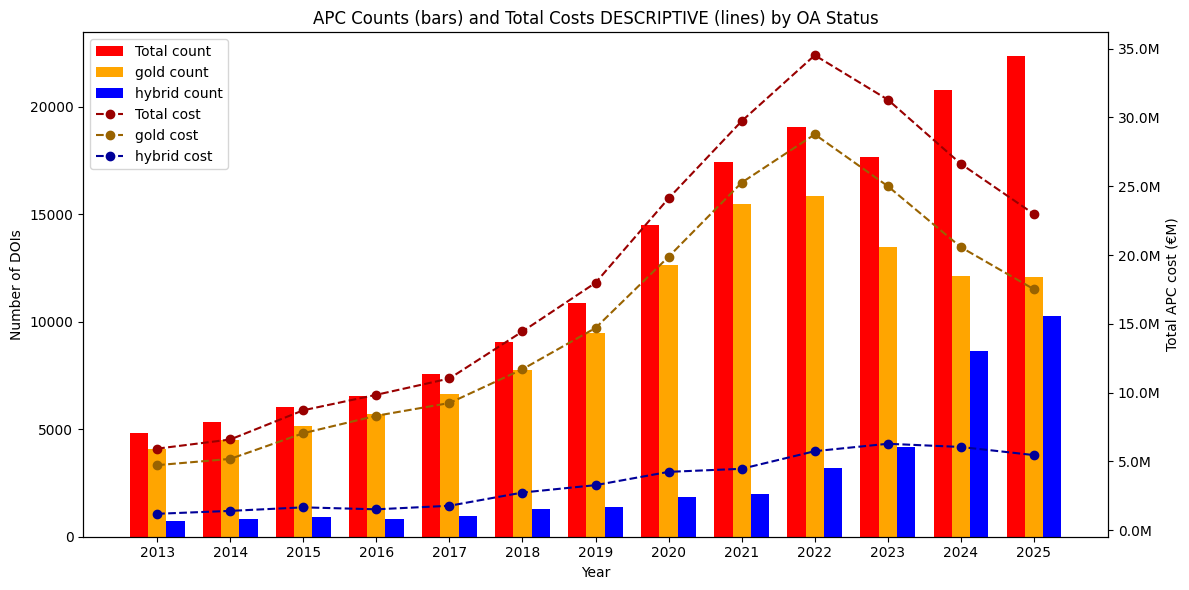

In [ ]:
df_inclusive_paid_tmp_1_oa_gold_hyb = df_inclusive_paid_tmp_1[df_inclusive_paid_tmp_1.oa_status.isin(['hybrid', 'gold'])].reset_index(drop = True)
status = df_inclusive_paid_tmp_1_oa_gold_hyb.groupby(['publication_year', 'oa_status']).agg({'doi':'count', 'fr_cost': 'sum'})
total = df_inclusive_paid_tmp_1_oa_gold_hyb.groupby(['publication_year']).agg({'doi':'count', 'fr_cost': 'sum'})
total['oa_status'] = 'Total'
total = total.set_index('oa_status', append = True)
df_data = pd.concat([status, total]).sort_index()

bar_width = 0.25
years = sorted(df_inclusive_paid_tmp_1_oa_gold_hyb.publication_year.unique())
x = np.arange(len(years))

fig, ax1 = plt.subplots(figsize=(12,6))

colors = {'gold':'orange', 'hybrid':'blue', 'Total':'red'}

def darken_color(color, amount=0.6):
    c = mcolors.to_rgb(color)
    return (c[0]*amount, c[1]*amount, c[2]*amount)

count_df = df_data['doi'].unstack('oa_status').fillna(0)
for i, col in enumerate(count_df.columns):
    ax1.bar(x + i*bar_width, count_df[col], width=bar_width, color=colors.get(col,'grey'), label=f"{col} count")

ax1.set_ylabel('Number of DOIs')
ax1.set_xlabel('Year')
ax1.set_xticks(x + bar_width)
ax1.set_xticklabels(years)

cost_df = df_data['fr_cost'].unstack('oa_status').fillna(0)
ax2 = ax1.twinx()
for col in cost_df.columns:
    dark_color = darken_color(colors.get(col,'grey'))
    ax2.plot(x + bar_width, cost_df[col], color=dark_color, marker='o', linestyle='--', label=f"{col} cost")

ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x*1e-6:.1f}M'))

ax2.set_ylabel('Total APC cost (€M)')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title('APC Counts (bars) and Total Costs DESCRIPTIVE (lines) by OA Status')
plt.tight_layout()
plt.show()

In [20]:
cost_df

oa_status,Total,gold,hybrid
publication_year,,,
2013,5.932850e+06,4.733749e+06,1.199101e+06
2014,6.598689e+06,5.188693e+06,1.409995e+06
2015,8.722952e+06,7.055532e+06,1.667419e+06
2016,9.847616e+06,8.323133e+06,1.524484e+06
2017,1.103211e+07,9.250086e+06,1.782024e+06
2018,1.445041e+07,1.170580e+07,2.744612e+06
2019,1.798649e+07,1.470465e+07,3.281837e+06
2020,2.412893e+07,1.988251e+07,4.246423e+06
2021,2.973850e+07,2.526913e+07,4.469371e+06
